**Decision Tree Theory and Applications**
Decision Trees are a popular machine learning algorithm used for both classification and regression tasks. They are based on the concept of recursive partitioning, where the data is divided into smaller subsets based on the values of the features.

**Theory**
A Decision Tree consists of nodes, edges, and leaves. Each node represents a feature, and the edges represent the possible values that the feature can take. The leaves represent the final outcome or prediction.

The algorithm works by selecting the best feature to split the data at each node, based on a criterion such as Gini impurity or entropy. The process is repeated recursively until a stopping criterion is met, such as a maximum depth or a minimum number of samples in a leaf node.

**Applications**
Decision Trees have many applications in various fields, including:

**Medical Diagnosis**
Decision Trees can be used to diagnose medical conditions based on symptoms and test results. For example, a Decision Tree could be used to diagnose whether a patient has a cold, the flu, or allergies based on their symptoms.

**Credit Scoring**
Decision Trees can be used to predict whether a loan applicant is likely to default on their loan. The features used could include credit score, income, employment history, and debt-to-income ratio.

**Marketing**
Decision Trees can be used to segment customers based on their demographics, purchasing behavior, and other factors. This can help marketers target their advertising and promotions more effectively.

**Image Recognition**
Decision Trees can be used for image recognition tasks, such as identifying objects in images. The features used could include color, texture, shape, and other visual cues.

**Advantages and Disadvantages**
Decision Trees have several advantages, including:

They are easy to interpret and visualize, making them a good choice for exploratory data analysis.
They can handle both categorical and numerical data.
They can handle missing values by using surrogate splits.
However, Decision Trees also have some disadvantages, including:

They can be prone to overfitting, especially if the trees are too deep.
They can be sensitive to noise in the data.
They can be computationally expensive for large datasets.
Conclusion
Decision Trees are a powerful and versatile machine learning algorithm that can be used for a wide range of tasks. Their ability to handle both categorical and numerical data, and their ease of interpretation make them a popular choice for many applications. However, care must be taken to avoid overfitting and to handle noise in the data.

# Teoría y Aplicación del Árbol de Decisiones en la Gestión Marino-Costera

## Objetivos del Módulo
- Comprender los fundamentos teóricos de los árboles de decisión
- Aplicar árboles de decisión a problemas de gestión marino-costera
- Interpretar resultados y visualizaciones de árboles
- Evitar overfitting mediante técnicas de pruning y parámetros de control

## Contexto Marino-Costero
Los árboles de decisión son herramientas poderosas para predecir fenómenos ambientales tales como:
- Calidad del agua basada en variables físico-químicas
- Presencia/ausencia de especies marinas
- Riesgo de erosión costera
- Clasificación de hábitats marinos


Teoría y Aplicación del Árbol de Decisiones en la Gestión Marino-Costera
1. Teoría del Árbol de Decisiones
Un árbol de decisiones es una herramienta de Machine Learning utilizada para predecir el valor de una variable objetivo a partir de varias variables predictoras. Se estructura como un árbol, donde cada nodo interno representa una "decisión" sobre el valor de una de las variables predictoras, y cada rama es el resultado de esa decisión, lo que conduce a otros nodos (decisiones) o a nodos terminales (resultados).

Componentes Clave:

Nodo Raíz: El punto de partida del árbol.
Nodos Internos: Representan decisiones basadas en las variables predictoras.
Ramas: Indicaciones del resultado de una decisión.
Nodos Hoja: Resultados finales que pueden ser una clase en clasificación o un valor en regresión.
Ventajas:

Fácil interpretación y visualización.
Puede manejar datos categóricos y numéricos.
Requiere poca preparación de datos.
Desventajas:

Puede sobreajustarse si no se poda adecuadamente.
Puede ser sensible a cambios en los datos.
2. Uso en la Gestión Marino-Costera
La gestión marino-costera se beneficia del uso de árboles de decisiones para predecir fenómenos como la calidad del agua, la biodiversidad o la erosión costera basándose en diversas variables ambientales y antropogénicas.

Ejemplo de Variables:

Predictoras: Temperatura del agua, salinidad, pH, concentración de nutrientes, presencia de especies invasoras.
Objetivo: Nivel de biodiversidad (alto, medio, bajo).
3. Caso de Uso Específico: Predicción del Nivel de Biodiversidad
Objetivo: Utilizar un árbol de decisiones para predecir el nivel de biodiversidad en una región costera basándose en variables ambientales.

Pasos del Caso de Uso:

Definir Variables:
Predictoras: Temperatura del agua, Salinidad, pH, Concentración de Nitratos.
Objetivo: Nivel de Biodiversidad (Bajo, Medio, Alto).
Recolección de Datos: Supongamos que tenemos datos históricos de estas variables.
Construcción del Árbol de Decisiones: Utilizaremos el paquete rpart en R.
Código en R para Simulación y Construcción del Árbol de Decisiones
Instalación de Paquetes y Preparación de Datos

## Criterios de División: Gini vs Entropía

### Impureza de Gini
La impureza de Gini mide la probabilidad de clasificar incorrectamente un elemento si se clasificara aleatoriamente:

$$	ext{Gini}(p) = 1 - \sum_{i=1}^{c} p_i^2$$

donde $p_i$ es la proporción de clase $i$ en el nodo.

**Características:**
- Rango: 0 (puro) a 0.5 (maximalmente impuro)
- Computacionalmente más eficiente
- Preferred en scikit-learn

### Entropía de Shannon
La entropía mide la incertidumbre o sorpresa esperada:

$$H(p) = -\sum_{i=1}^{c} p_i \log_2(p_i)$$

**Características:**
- Rango: 0 (puro) a $\log_2(c)$ (maximalmente impuro)
- Basada en teoría de información
- Valores ligeramente distintos a Gini

### Conclusión
Ambos criterios son similares en práctica; Gini es más rápido computacionalmente.


In [1]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Set seed for reproducibility
np.random.seed(42)

# Simulate data for marine biodiversity classification
n = 100
temperatura = np.random.uniform(15, 30, n)  # Temperature in Celsius
salinidad = np.random.uniform(30, 40, n)    # Salinity in PSU
pH = np.random.uniform(7, 9, n)             # pH
nitratos = np.random.uniform(0, 10, n)      # Nitrate concentration in mg/L

# Simulate biodiversity classification based on environmental conditions
score = 0.5*temperatura + 0.3*salinidad - 0.2*pH + 0.1*nitratos + np.random.normal(0, 1, n)
# Use quantile-based bins for balanced class distribution
quantiles = np.percentile(score, [33.3, 66.7])
biodiversidad = pd.cut(score,
                       bins=[-np.inf, quantiles[0], quantiles[1], np.inf],
                       labels=["Bajo", "Medio", "Alto"])

# Create DataFrame
datos = pd.DataFrame({
    "temperatura": temperatura,
    "salinidad": salinidad,
    "pH": pH,
    "nitratos": nitratos,
    "biodiversidad": biodiversidad
})

print("Data sample:")
print(datos.head())
print(f"\nData shape: {datos.shape}")
print(f"\nBiodiversity class distribution:")
print(datos["biodiversidad"].value_counts())

# Prepare features and target
X = datos[["temperatura", "salinidad", "pH", "nitratos"]]
y = datos["biodiversidad"]

# Split data with stratification to maintain class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")


Data sample:
   temperatura  salinidad        pH  nitratos biodiversidad
0    20.618102  30.314292  8.284063  0.516817          Bajo
1    29.260715  36.364104  7.168280  5.313546          Alto
2    25.979909  33.143560  7.323257  5.406351          Alto
3    23.979877  35.085707  8.797108  6.374299         Medio
4    17.340280  39.075665  8.212858  7.260913         Medio

Data shape: (100, 5)

Biodiversity class distribution:
biodiversidad
Medio    34
Bajo     33
Alto     33
Name: count, dtype: int64

Training set size: 80
Test set size: 20


## Nota sobre la Implementación en R

La versión en R también está disponible. En este notebook trabajamos con la implementación en Python usando scikit-learn.

En R, usarías:
- `rpart()`: para crear el árbol
- `rpart.plot()`: para visualizar
- `predict()`: para hacer predicciones

Sin embargo, scikit-learn en Python ofrece una interfaz más intuitiva y se integra mejor con el ecosistema de análisis científico.


Tree depth: 5
Number of leaves: 16


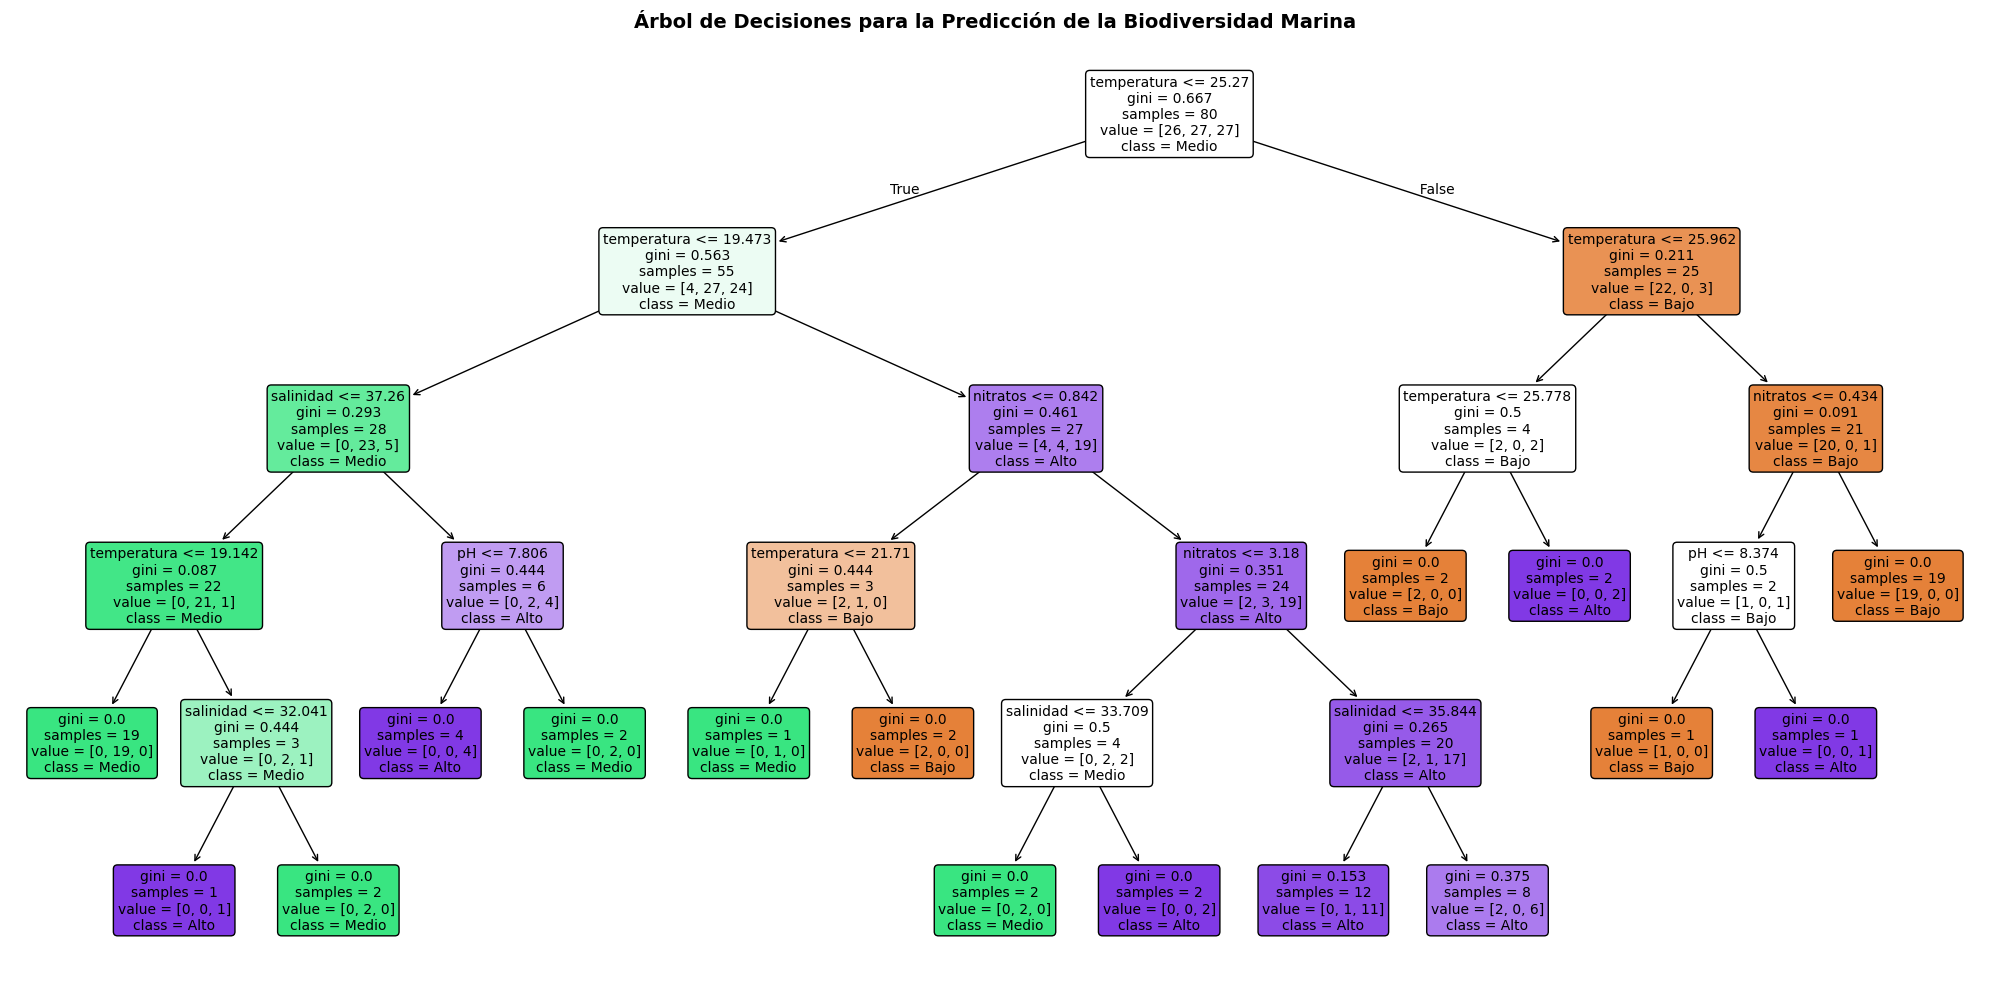

In [2]:
# Create and train decision tree classifier with max_depth to prevent overfitting
modelo_arbol = DecisionTreeClassifier(
    max_depth=5,
    random_state=42,
    criterion='gini'
)

modelo_arbol.fit(X_train, y_train)

print(f"Tree depth: {modelo_arbol.get_depth()}")
print(f"Number of leaves: {modelo_arbol.get_n_leaves()}")

# Visualize the tree
plt.figure(figsize=(20, 10))
plot_tree(
    modelo_arbol,
    feature_names=["temperatura", "salinidad", "pH", "nitratos"],
    class_names=["Bajo", "Medio", "Alto"],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Árbol de Decisiones para la Predicción de la Biodiversidad Marina", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


Training Accuracy: 0.9625
Test Accuracy: 0.5000
Overfitting gap: 0.4625

Confusion Matrix:
[[3 3 0]
 [3 3 1]
 [0 3 4]]


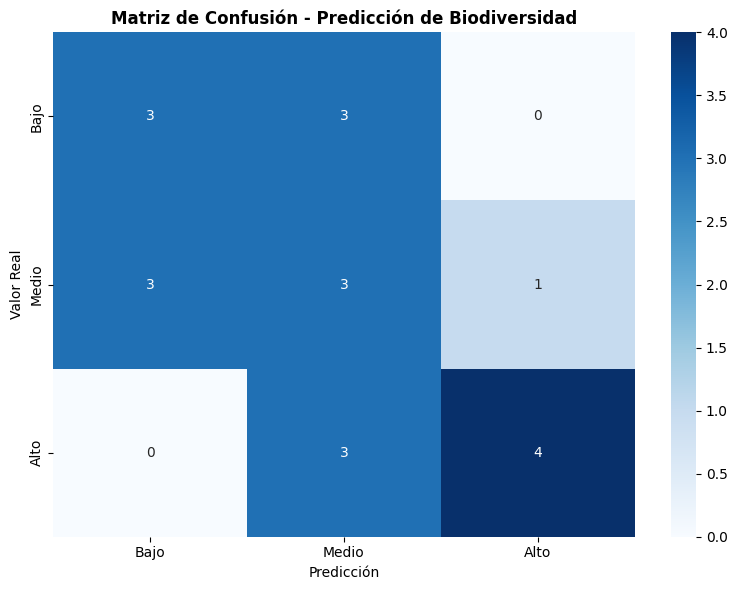


Classification Report:
              precision    recall  f1-score   support

        Alto       0.80      0.57      0.67         7
        Bajo       0.50      0.50      0.50         6
       Medio       0.33      0.43      0.38         7

    accuracy                           0.50        20
   macro avg       0.54      0.50      0.51        20
weighted avg       0.55      0.50      0.51        20



In [3]:
# Make predictions
y_pred = modelo_arbol.predict(X_test)
y_pred_train = modelo_arbol.predict(X_train)

# Evaluate model
train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Overfitting gap: {train_accuracy - test_accuracy:.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=["Bajo", "Medio", "Alto"])
print("\nConfusion Matrix:")
print(cm)

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Bajo", "Medio", "Alto"],
            yticklabels=["Bajo", "Medio", "Alto"])
plt.title("Matriz de Confusión - Predicción de Biodiversidad", fontweight='bold')
plt.ylabel("Valor Real")
plt.xlabel("Predicción")
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


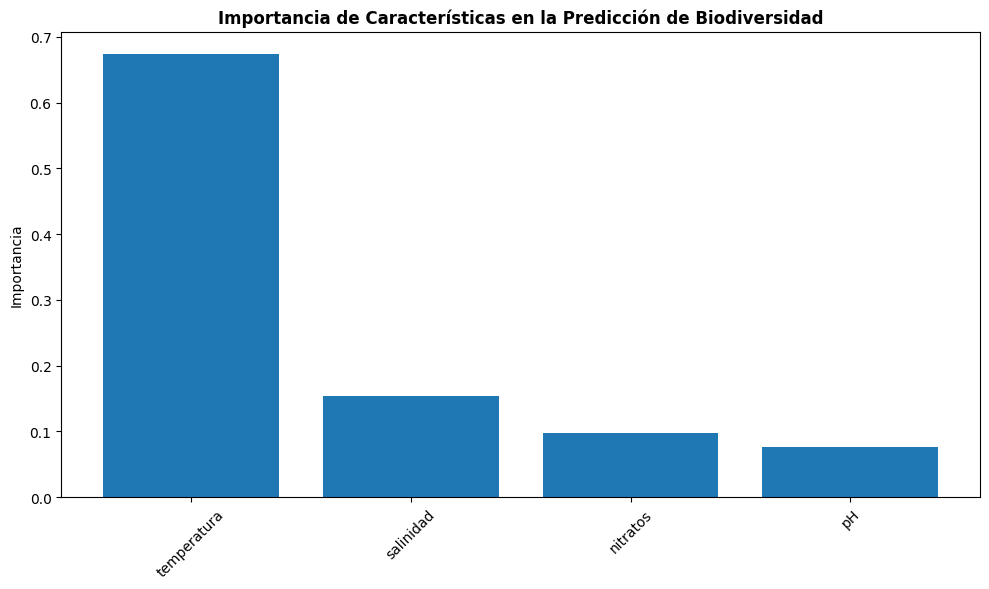

Feature Importance:
  temperatura: 0.6737
  salinidad: 0.1534
  nitratos: 0.0973
  pH: 0.0756


In [4]:
# Feature importance
feature_importance = modelo_arbol.feature_importances_
features = ["temperatura", "salinidad", "pH", "nitratos"]

# Sort by importance
sorted_idx = np.argsort(feature_importance)[::-1]

plt.figure(figsize=(10, 6))
plt.bar(range(len(sorted_idx)), feature_importance[sorted_idx], align='center')
plt.xticks(range(len(sorted_idx)), [features[i] for i in sorted_idx], rotation=45)
plt.ylabel('Importancia')
plt.title('Importancia de Características en la Predicción de Biodiversidad', fontweight='bold')
plt.tight_layout()
plt.show()

print("Feature Importance:")
for i, idx in enumerate(sorted_idx):
    print(f"  {features[idx]}: {feature_importance[idx]:.4f}")


## Ejercicios para el Estudiante

### Ejercicio 1: Ajuste de Hiperparámetros
Modifica el árbol de decisión con diferentes valores de `max_depth` (3, 5, 7, 10) y `min_samples_split` (2, 5, 10).
¿Cuál combinación da el mejor balance entre precisión de entrenamiento y prueba?

**Pista:** Usa un bucle para probar múltiples combinaciones y registra los resultados en un DataFrame.

### Ejercicio 2: Análisis de Overfitting
Crea un gráfico que muestre la relación entre `max_depth` y la precisión de entrenamiento/prueba.
¿A partir de qué profundidad comienza el overfitting?

### Ejercicio 3: Predicción en Nuevos Datos
Crea tres observaciones nuevas con valores realistas de temperatura, salinidad, pH y nitratos.
Usa el modelo entrenado para predecir el nivel de biodiversidad.
¿Tiene sentido la predicción según los valores de entrada?

```python
# Template para Ejercicio 3
nuevos_datos = pd.DataFrame({
    "temperatura": [25, 20, 15],
    "salinidad": [35, 32, 38],
    "pH": [8.2, 7.8, 8.0],
    "nitratos": [2, 5, 8]
})

# Tu código aquí
predicciones_nuevas = ...
```
